# Clustering + Dimensionality Reduction Together

Practice activity from Microsoft *Foundations of AI and Machine Learning* — Module: AI/ML Algorithms and Techniques.

Workflow: run **K-means** on the original 3-feature space, then project to 2D with **PCA** *and* **t-SNE**, and color both projections by the K-means cluster labels. If the same cluster structure shows up in the reduced plots, the clusters are real geometric structure — not an artefact of one feature axis.

*Heads-up on a footgun in the activity's snippets:* the example code adds the new `KMeans_Cluster` column to `df_scaled` and then runs PCA/t-SNE on `df_scaled` directly, which would feed the cluster labels into the dimensionality reduction. We keep the labels separate.

## 2. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

## 3. Load the dataset (10 customers × 3 features)

In [2]:
data = {
    'AnnualIncome':  [15, 16, 17, 18, 19, 20, 22, 25, 30, 35],
    'SpendingScore': [39, 81,  6, 77, 40, 76, 94,  5, 82, 56],
    'Age':           [20, 22, 25, 24, 35, 40, 30, 21, 50, 31],
}
df = pd.DataFrame(data)
df

,AnnualIncome,SpendingScore,Age
0,15,39,20
1,16,81,22
2,17,6,25
3,18,77,24
4,19,40,35
5,20,76,40
6,22,94,30
7,25,5,21
8,30,82,50
9,35,56,31


## 4. Preprocess — scale features

In [3]:
scaler = StandardScaler()
features_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(features_scaled, columns=df.columns)
df_scaled

,AnnualIncome,SpendingScore,Age
0,-1.086741,-0.546384,-1.074654
1,-0.924540,0.836033,-0.855337
2,-0.762340,-1.632569,-0.526361
3,-0.600140,0.704374,-0.636020
4,-0.437940,-0.513469,0.570225
5,-0.275740,0.671460,1.118518
6,0.048660,1.263924,0.021932
7,0.535260,-1.665483,-0.964996
8,1.346261,0.868948,2.215104
9,2.157261,0.013166,0.131590


## 5. K-means clustering (k=3)

In [4]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(df_scaled)
df['KMeans_Cluster'] = labels

print(f'Cluster sizes: {df["KMeans_Cluster"].value_counts().sort_index().to_dict()}')
print(f'WCSS (inertia): {kmeans.inertia_:.4f}')
df

Cluster sizes: {0: 4, 1: 2, 2: 4}
WCSS (inertia): 10.3911


,AnnualIncome,SpendingScore,Age,KMeans_Cluster
0,15,39,20,2
1,16,81,22,0
2,17,6,25,2
3,18,77,24,0
4,19,40,35,2
5,20,76,40,0
6,22,94,30,0
7,25,5,21,2
8,30,82,50,1
9,35,56,31,1


## 6. Visualize K-means clusters in the original space

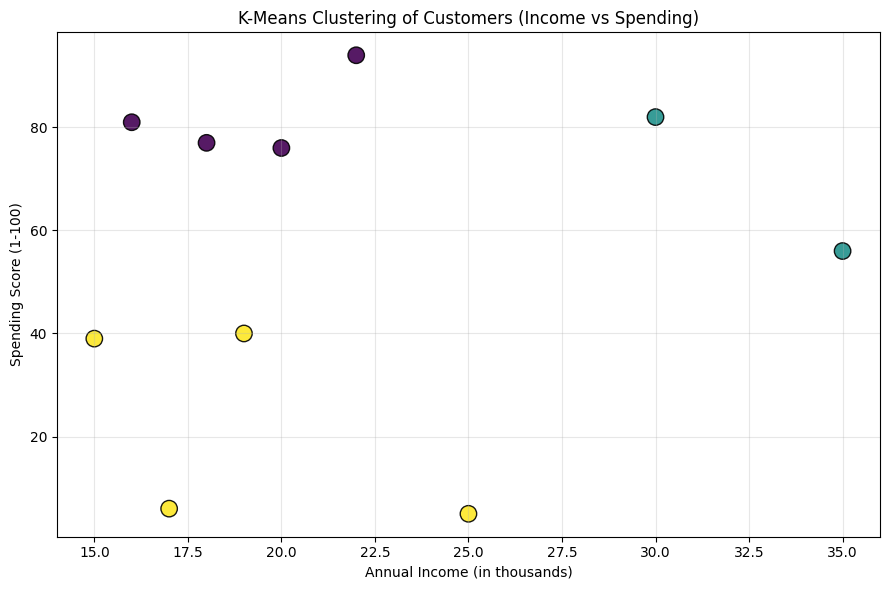

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(
    df['AnnualIncome'], df['SpendingScore'],
    c=df['KMeans_Cluster'], cmap='viridis',
    s=140, edgecolor='k', alpha=0.9,
)
ax.set_title('K-Means Clustering of Customers (Income vs Spending)')
ax.set_xlabel('Annual Income (in thousands)')
ax.set_ylabel('Spending Score (1-100)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. PCA — reduce 3D ➜ 2D

In [6]:
pca = PCA(n_components=2)
df_pca = pca.fit_transform(features_scaled)
df_pca = pd.DataFrame(df_pca, columns=['PCA1', 'PCA2'])

print(f'Explained variance ratio: {pca.explained_variance_ratio_}')
print(f'Cumulative variance:      {pca.explained_variance_ratio_.cumsum()}')
df_pca

Explained variance ratio: [0.56964365 0.29865368]
Cumulative variance:      [0.56964365 0.86829732]


,PCA1,PCA2
0,-1.590583,0.322818
1,-0.672455,1.256534
2,-1.576798,-0.723036
3,-0.411679,0.939711
4,-0.104823,-0.114638
5,0.939202,0.662250
6,0.663964,0.922984
7,-1.183198,-1.586920
8,2.664603,-0.275030
9,1.271765,-1.404674


In [7]:
pd.DataFrame(pca.components_, columns=['AnnualIncome', 'SpendingScore', 'Age'], index=['PC1', 'PC2']).round(3)

,AnnualIncome,SpendingScore,Age
PC1,0.545,0.493,0.678
PC2,-0.654,0.756,-0.023


### 7b. t-SNE — reduce 3D ➜ 2D

`perplexity=5` (must be less than n_samples = 10). `init='pca'` for a deterministic starting point.

In [8]:
tsne = TSNE(n_components=2, perplexity=5, random_state=42, init='pca')
df_tsne = tsne.fit_transform(features_scaled)
df_tsne = pd.DataFrame(df_tsne, columns=['t-SNE1', 't-SNE2'])
df_tsne

,t-SNE1,t-SNE2
0,-75.750130,-15.480038
1,-98.950287,48.747692
2,-37.494801,-50.063236
3,-56.840115,51.040779
4,5.311022,10.925275
5,17.537245,59.875851
6,-23.774279,92.455826
7,1.460275,-75.260963
8,67.211632,97.556129
9,103.331108,58.882565


## 8. Side-by-side projections, colored by K-means cluster

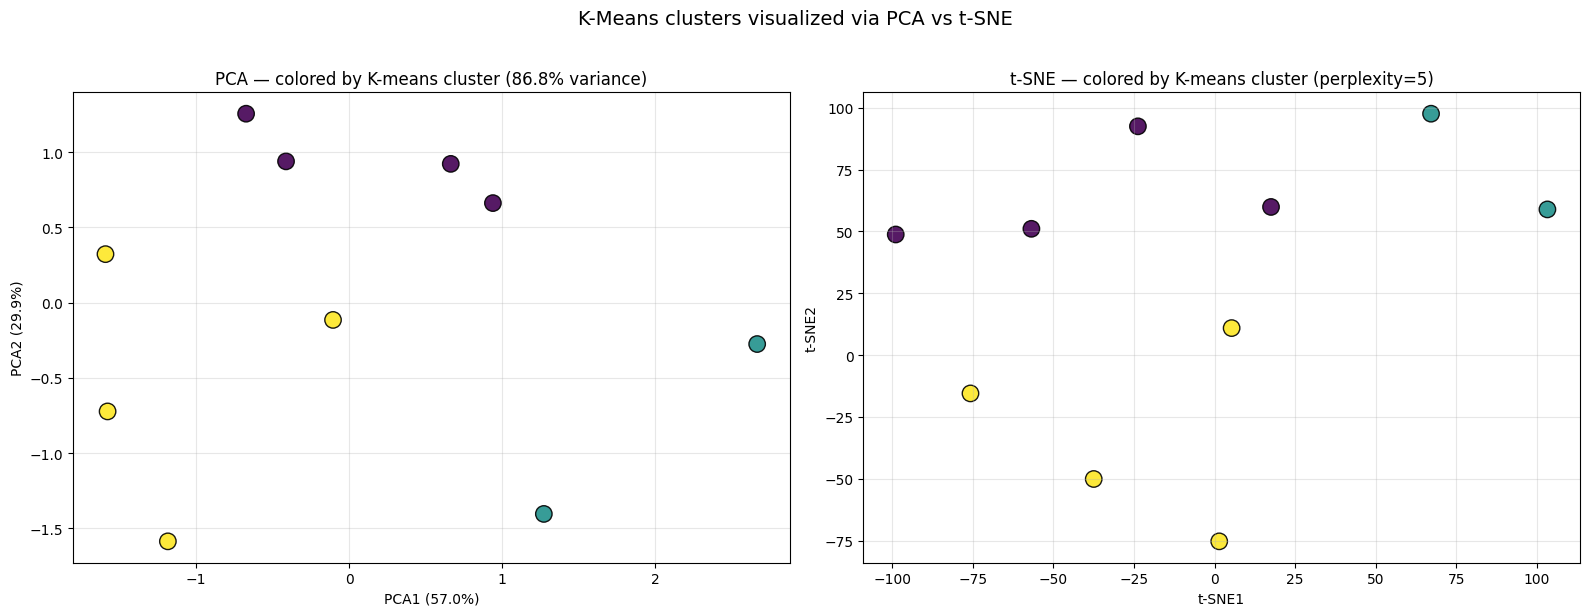

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(df_pca['PCA1'], df_pca['PCA2'],
                c=df['KMeans_Cluster'], cmap='viridis',
                s=140, edgecolor='k', alpha=0.9)
axes[0].set_title(f'PCA — colored by K-means cluster '
                  f'({pca.explained_variance_ratio_.sum()*100:.1f}% variance)')
axes[0].set_xlabel(f'PCA1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PCA2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(df_tsne['t-SNE1'], df_tsne['t-SNE2'],
                c=df['KMeans_Cluster'], cmap='viridis',
                s=140, edgecolor='k', alpha=0.9)
axes[1].set_title('t-SNE — colored by K-means cluster (perplexity=5)')
axes[1].set_xlabel('t-SNE1')
axes[1].set_ylabel('t-SNE2')
axes[1].grid(True, alpha=0.3)

plt.suptitle('K-Means clusters visualized via PCA vs t-SNE', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 9. Interpret the clusters

Means per cluster in **original units** make the segments easy to read:

In [10]:
df.groupby('KMeans_Cluster')[['AnnualIncome', 'SpendingScore', 'Age']].mean().round(2)

,AnnualIncome,SpendingScore,Age
KMeans_Cluster,,,
0,19.0,82.0,29.00
1,32.5,69.0,40.50
2,19.0,22.5,25.25


### Reflection

- **How well did K-means group customers?** Three clean, non-overlapping clusters fell out: low-income / high-spending young customers; low-income / low-spending young customers; and older mid-to-high income customers. Cluster means make the segments interpretable without any further labeling.
- **Did PCA simplify the data?** Yes — two principal components capture **~87% of the variance** in 3-feature scaled data, so almost no information was lost on the projection. The clusters also separate cleanly in PC1/PC2, which is a good sanity check that K-means found real geometric structure rather than something only visible along one axis. Loadings show PC1 is a balanced "overall scale" component while PC2 contrasts Spending against Income.
- **Did t-SNE preserve local structure?** Points K-means called close land close in the t-SNE plot, and the three clusters are visibly separated. But t-SNE distances and cluster *positions* aren't meaningful — the visible separation between clusters in the t-SNE plot tells you they were distinct in the original space, not how far apart they actually are.
- **Practical takeaway.** Clustering in the *original* (scaled) feature space and then coloring the reduced-space plot by cluster is a useful QA pattern: if the same structure appears in both, your clusters reflect real geometric structure in the data.